# Homework 03: Learning Curves and Training Workflow

#### Due Date: Sunday, September 20th at 11:59pm (with 2 hour plus 1 minute grace period)

#### The late policy is described in the DX 703 Syllabus. 

In this assignment, you will learn how to design, train, and evaluate neural networks by systematically exploring key design choices. Your focus will be on developing an effective **training workflow** — using learning curves and validation metrics to guide your decisions.

We'll again use the **Forest Cover Type (Covertype) dataset,** which has ~581k tabular records with 54 cartographic/topographic features (elevation, aspect, slope, soil and wilderness indicators) used to predict one of seven tree cover types in Colorado’s Roosevelt National Forest. 

We will start with a **baseline model** (two hidden layers of sizes 64 and 32), and gradually introduce and tune different hyperparameters. Each of the first five problems considers  different hyperparameter choices, and the last problem is your chance to use what you have learned to design your best model:

1. **Activation function** – Compare ReLU, sigmoid, and tanh to see which provides the best accuracy.
2. **Learning rate** – Explore a range of learning rates and identify which balances convergence speed and stability.
3. **Dropout** – Investigate how different dropout rates reduce overfitting and where they are most effective.
4. **L2 regularization** – Experiment with weight penalties to encourage simpler models and avoid memorization.
5. **Dropout + L2** – Combine both regularization techniques and study their interaction.
6. **Best model design** – Use all your insights to build and train your strongest model, with the option to try **learning rate scheduling** for further improvement.

In this homework, you will use **early stopping** to select the "best" model at the epoch of **minimum validation loss**, and you will report the **validation accuracy** of that selected model as the primary measure of performance. Test accuracy is reported for reference but is not used for model selection.

> **Note:** Throughout this homework, best always refers to the model selected by early stopping at the epoch of minimum validation loss. Do not report metrics from the final training epoch unless explicitly instructed.

By the end of this homework, you will not only understand how different hyperparameters affect training and generalization, but also gain hands-on practice in building a disciplined workflow for model development.

There are 10 graded problems, worth 8 points each, with 5 points for free if you complete the homework. 

In [1]:
# Useful imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import time
import os

from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.utils import class_weight

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input,Dropout
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers.schedules import ExponentialDecay


from tensorflow.keras.datasets import fashion_mnist

# utility code

random_seed = 42

def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Suppresses INFO and WARNING messages


In [2]:
# Utility function to plot learning curves and keep track of all results

# Call `print_results()` to see listing of all results logged so far


def plot_learning_curves(hist, title, verbose=True):
    
    val_losses = hist.history['val_loss']
    min_val_loss = min(val_losses)
    min_val_epoch = val_losses.index(min_val_loss)
    val_acc_at_min_loss = hist.history['val_accuracy'][min_val_epoch]

    epochs = range(1, len(val_losses) + 1)  # epoch numbers starting at 1

    fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

    # --- Loss Plot ---
    axs[0].plot(epochs, hist.history['loss'], label='train loss')
    axs[0].plot(epochs, hist.history['val_loss'], label='val loss')
    axs[0].scatter(min_val_epoch + 1, min_val_loss, color='red', marker='x', s=50, label='min val loss')
    axs[0].set_title(f'{title} - Categorical Cross-Entropy Loss')
    axs[0].set_ylabel('Loss')
    axs[0].legend()
    axs[0].grid(True)

    # --- Accuracy Plot ---
    axs[1].plot(epochs, hist.history['accuracy'], label='train acc')
    axs[1].plot(epochs, hist.history['val_accuracy'], label='val acc')
    axs[1].scatter(min_val_epoch + 1, val_acc_at_min_loss, color='red', marker='x', s=50, label='acc @ min val loss')
    axs[1].set_title(f'{title} - Accuracy')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Accuracy')
    axs[1].legend()
    axs[1].grid(True)
    axs[1].set_ylim(0, 1.05)

    plt.tight_layout()
    plt.show()

    if verbose:
        print(f"Final Training Loss:            {hist.history['loss'][-1]:.4f}")
        print(f"Final Training Accuracy:        {hist.history['accuracy'][-1]:.4f}")
        print(f"Final Validation Loss:          {hist.history['val_loss'][-1]:.4f}")
        print(f"Final Validation Accuracy:      {hist.history['val_accuracy'][-1]:.4f}")
        print(f"Minimum Validation Loss:        {min_val_loss:.4f} (Epoch {min_val_epoch + 1})")
        print(f"Validation Accuracy @ Min Loss: {val_acc_at_min_loss:.4f}")

    results[title] = (val_acc_at_min_loss,min_val_epoch + 1)

results = {}

**The plotting function will record the validation accuracy for each experiment, using the plot title as key. The next function will print these out (see the last cell in the notebook).**


In order to see all results, you must give a different plot title to each experiment.

In [3]:
def print_results():
    for title, (acc, ep) in sorted(results.items(), 
                                   key=lambda kv: kv[1][0],   # kv[1] is (acc, epoch); [0] is acc
                                   reverse=True
                                  ):
        print(f"{title:<40}\t{acc:.4f}")

### Wrapper to train, display results, and run test set

We assume multi-class classification, and allow setting various parameters for training. 

In [4]:
# Uses globals X_train,y_train,X_val,y_val

def train_and_test(model, 
                   epochs        = 500,                   # Just needs to be bigger than early stop point
                   lr_schedule   = 0.001,                 # Adam default / 10 seems to work well for this dataset
                   optimizer     = "Adam",
                   title         = "Learning Curves",
                   batch_size    = 64,                     # experiments confirmed this was optimal with other parameters at default
                   use_early_stopping = True,
                   patience      = 10,                                       
                   min_delta     = 0.0001,                 
                   callbacks     = [],                     # for extra callbacks other than early stopping
                   verbose       = 0,
                   return_history = False
                  ):

    print(f"\n{title}\n")


    if optimizer == "Adam":
        opt = Adam(learning_rate=lr_schedule) 
    else:
        opt = optimizer
    
    #Compiling the model
    model.compile(optimizer=opt, 
                  loss="sparse_categorical_crossentropy", 
                  metrics=["accuracy"]
                 )

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=patience,
        min_delta=min_delta,
        restore_best_weights=True,               # this will mean that the model which produced the smallest validation loss will be returned
        verbose=verbose
    )
    

    if use_early_stopping:
        cbs=[early_stop] + callbacks
    else:
        cbs=callbacks

    # start timer
    start = time.time()
    
    # Fit the model with early stopping
    history = model.fit(X_train, y_train,
                        epochs=epochs,
                        batch_size=batch_size,
                        validation_data=(X_val, y_val),       # must use stratified validation set
                        callbacks=cbs,
                        verbose=verbose
                       )

    if use_early_stopping:
        best_epoch = early_stop.best_epoch
        best_acc   = history.history['val_accuracy'][best_epoch]
    else:
        best_epoch = np.argmax(history.history['val_accuracy'])
        best_acc   = history.history['val_accuracy'][best_epoch]
    
    # Plot training history
    plot_learning_curves(history, title=title)

    # Evaluate on test data
    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
    
    print(f"\nTest Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")

    print(f"\nValidation-Test Gap (accuracy): {abs(best_acc - test_accuracy):.6f}")
    
    # Record end time and print execution time
    end = time.time()
    print(f"\nExecution Time: " + format_hms(end-start))

    if return_history:
        return history

### Load the dataset and extract a stratified subset

This data set is rather large (581,012 samples) and unbalanced, but for the purposes of this homework, we use a much smaller set, and select samples so that it is balanced. 

In [5]:
# complete cell: load, balance, split into X_train/y_train/x_val/y_val/X_test/y_test, and standardize
from collections import Counter
from sklearn.datasets import fetch_covtype
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# 1) load
x, y = fetch_covtype(return_X_y=True)  # y in {1..7}
print("full dataset shape:", x.shape)

# 2) build a perfectly balanced subset across 7 classes (no replacement)
classes, counts = np.unique(y, return_counts=True)
# min_count = counts.min()  # size of rarest class                         # You can modify this parameter to increase the size of the dataset, but above
min_count = 1000                                                           # counts.min() you'll produce an unbalanced set. 


rng = np.random.default_rng(42)

idx_list = []
for c in classes:
    c_idx = np.where(y == c)[0]
    chosen = rng.choice(c_idx, size=min_count, replace=False)
    idx_list.append(chosen)

idx_bal = np.concatenate(idx_list)
rng.shuffle(idx_bal)

X_sub = x[idx_bal]
y_sub = y[idx_bal] - 1  # relabel to {0..6} for keras
print("balanced subset shape:", X_sub.shape, "class counts:", dict(Counter(y_sub)))

# 3) stratified 60/20/20 split (train/val/test)
test_size = 0.20
val_size = 0.20  # of the whole dataset

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_sub, y_sub, test_size=test_size, random_state=random_seed, stratify=y_sub
)
val_size_rel = val_size / (1.0 - test_size)  # e.g., 0.20 / 0.80 = 0.25

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=val_size_rel, random_state=random_seed, stratify=y_trainval
)

# 4) standardize using train-only stats (float32 for tensorflow friendliness)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_val   = scaler.transform(X_val).astype(np.float32)
X_test  = scaler.transform(X_test).astype(np.float32)

# 5) quick sanity checks
def show_counts(name, y_arr):
    c = Counter(y_arr)
    total = sum(c.values())
    print(f"{name}: total={total}, per-class={dict(c)}")

print("shapes:", "X_train", X_train.shape, "X_val", X_val.shape, "X_test", X_test.shape)
show_counts("train", y_train)
show_counts("val  ", y_val)
show_counts("test ", y_test)

# you now have: X_train, y_train, X_val, y_val, X_test, y_test

# Looks like integer encoded multi-class, let's check and define the global n_classes

labels = np.unique(y_train)

n_classes = len(labels)

print("class labels:",labels)


full dataset shape: (581012, 54)
balanced subset shape: (7000, 54) class counts: {np.int32(2): 1000, np.int32(0): 1000, np.int32(4): 1000, np.int32(5): 1000, np.int32(1): 1000, np.int32(3): 1000, np.int32(6): 1000}
shapes: X_train (4200, 54) X_val (1400, 54) X_test (1400, 54)
train: total=4200, per-class={np.int32(2): 600, np.int32(1): 600, np.int32(0): 600, np.int32(3): 600, np.int32(5): 600, np.int32(4): 600, np.int32(6): 600}
val  : total=1400, per-class={np.int32(1): 200, np.int32(6): 200, np.int32(5): 200, np.int32(4): 200, np.int32(3): 200, np.int32(2): 200, np.int32(0): 200}
test : total=1400, per-class={np.int32(0): 200, np.int32(6): 200, np.int32(2): 200, np.int32(3): 200, np.int32(4): 200, np.int32(5): 200, np.int32(1): 200}
class labels: [0 1 2 3 4 5 6]


## Prelude: Defining a model builder

In order to facilitate our experimentation, we'll write a function which builds models according to specifications:

- How many layers
- How wide each layer is
- How much dropout in each layer
- How much L2 Regularization in each layer

This is a fairly standard practice in ML, since the structure of simple models is fairly predictable and can be specified by a few hyperparameters. 

In [6]:
# This function will build a multi-class classifier with dropout and L2 regularization.
# You must specify the number of input features, the number of classes, and a list of layer hyperparameters
# in the form  [ ...., (width, activation function, L2 lambda, dropout rate), .... ]

# Note that when adding dropout, this appears as a separate layer, but it has no parameters to be trained. 

def build_model(n_inputs,layer_list,n_classes):
    layers = [ Input(shape=(n_inputs,)) ]
    for (width,act,l2_lambda,dropout_rate) in layer_list:
        layers.append( Dense(width, activation=act, kernel_regularizer=regularizers.l2(l2_lambda)) )
        if dropout_rate > 0:
            layers.append( Dropout(dropout_rate) )
    layers.append( Dense(n_classes, activation='softmax') )
    return models.Sequential( layers )


**Example: To build the following model:**

In [7]:
model = models.Sequential(
   [
    Input(shape=(X_train.shape[1],)),                              
    Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.0)),              # 0.0 means no regularization applied; no dropout, so no Dropout layer necessary
    Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.3),
    Dense(n_classes, activation='softmax')
   ]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         3,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,831 (22.78 KB)

 Trainable params: 5,831 (22.78 KB)

 Non-trainable params: 0 (0.00 B)

**We call `build_model` as shown here:**

In [8]:
build_model(X_train.shape[1], [ (64,'relu',0.0,0.0), (32,'relu',0.001,0.3)], n_classes).summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         3,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,831 (22.78 KB)

 Trainable params: 5,831 (22.78 KB)

 Non-trainable params: 0 (0.00 B)

-------------------



### Baseline Model Architecture

**Problems 1–5 will use the following baseline model structure,** implemented with the provided `build_model` function and trained using `train_and_test`:

```
input → 64 → 32 → output
```

* Two hidden layers of widths 64 and 32.
* Activation function, dropout rate, and L2 regularization term (λ) will vary as specified in each problem.
* **Early stopping** is always applied to select the model at the epoch of **minimum validation loss**.
* We will report the **validation accuracy** of the selected model as the primary metric.


### Problem One: Which Activation Function?

In this problem, you will train the **baseline neural network** and investigate which activation function produces the best performance. The model you create will be the one saved by **early stopping** — that is, the epoch where validation loss is minimized.

**Steps to follow:**

* Use the provided functions `train_and_test` and `build_model` to create a model named **`model_baseline`**.
* Train and evaluate this model using each of the following activation functions in the hidden layers:

  * `relu`
  * `sigmoid`
  * `tanh`
* Identify which activation function produces the **best validation accuracy** at the epoch of **minimum validation loss**.
* Answer the graded questions.


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │         3,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,831 (22.78 KB)

 Trainable params: 5,831 (22.78 KB)

 Non-trainable params: 0 (0.00 B)

None

Learning Curves



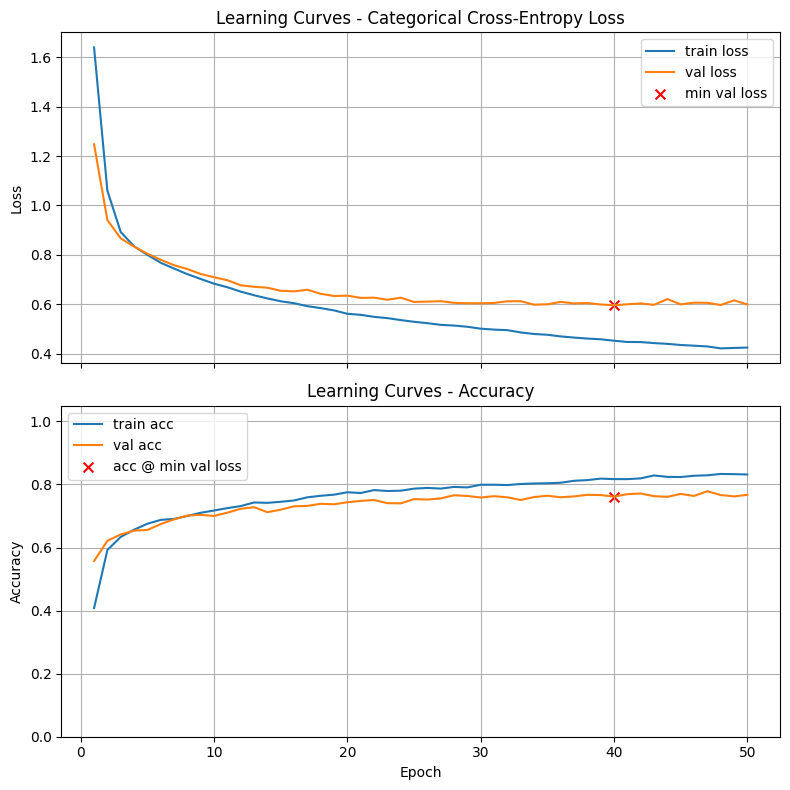

Final Training Loss:            0.4246
Final Training Accuracy:        0.8317
Final Validation Loss:          0.5993
Final Validation Accuracy:      0.7671
Minimum Validation Loss:        0.5958 (Epoch 40)
Validation Accuracy @ Min Loss: 0.7614

Test Loss: 0.5992
Test Accuracy: 0.7550

Validation-Test Gap (accuracy): 0.006429

Execution Time: 00:00:05


In [9]:
model_baseline_relu = build_model(
    n_inputs=X_train.shape[1], 
    # (width, act, l2_lambda, dropout_rate)
    layer_list=[
        (64, 'relu', 0.0, 0.0), 
        (32, 'relu', 0.0, 0.0)
    ], 
    n_classes=n_classes
)
print(model_baseline_relu.summary())
train_and_test(model=model_baseline_relu)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 64)             │         3,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,831 (22.78 KB)

 Trainable params: 5,831 (22.78 KB)

 Non-trainable params: 0 (0.00 B)

None

Learning Curves



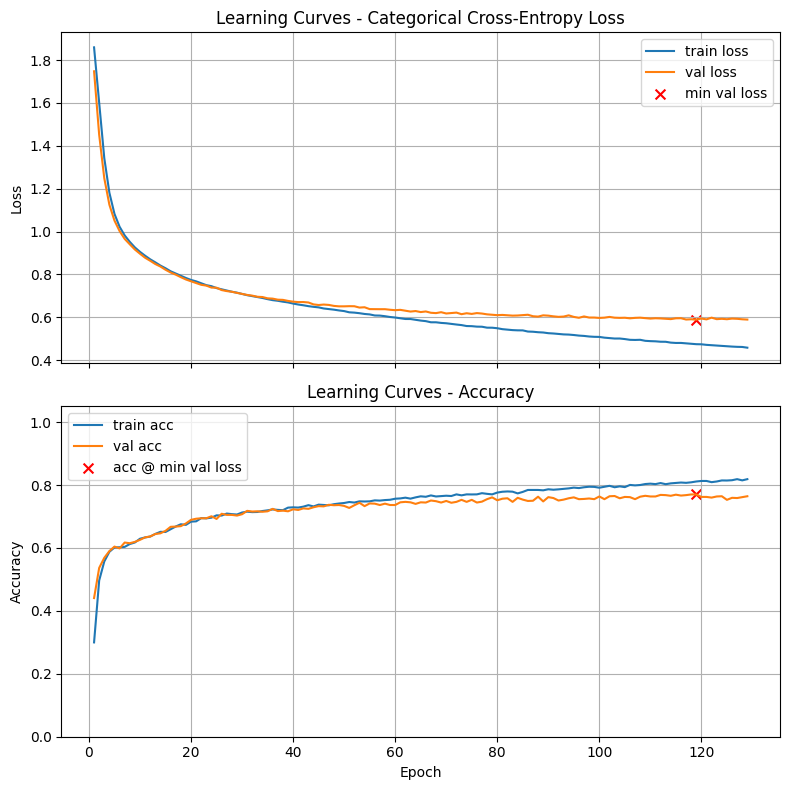

Final Training Loss:            0.4580
Final Training Accuracy:        0.8186
Final Validation Loss:          0.5892
Final Validation Accuracy:      0.7643
Minimum Validation Loss:        0.5890 (Epoch 119)
Validation Accuracy @ Min Loss: 0.7700

Test Loss: 0.5930
Test Accuracy: 0.7550

Validation-Test Gap (accuracy): 0.015000

Execution Time: 00:00:13


In [10]:
model_baseline_sigmoid = build_model(
    n_inputs=X_train.shape[1], 
    # (width, act, l2_lambda, dropout_rate)
    layer_list=[
        (64, 'sigmoid', 0.0, 0.0), 
        (32, 'sigmoid', 0.0, 0.0)
    ], 
    n_classes=n_classes
)
print(model_baseline_sigmoid.summary())
train_and_test(model=model_baseline_sigmoid)

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 64)             │         3,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,831 (22.78 KB)

 Trainable params: 5,831 (22.78 KB)

 Non-trainable params: 0 (0.00 B)

None

Learning Curves



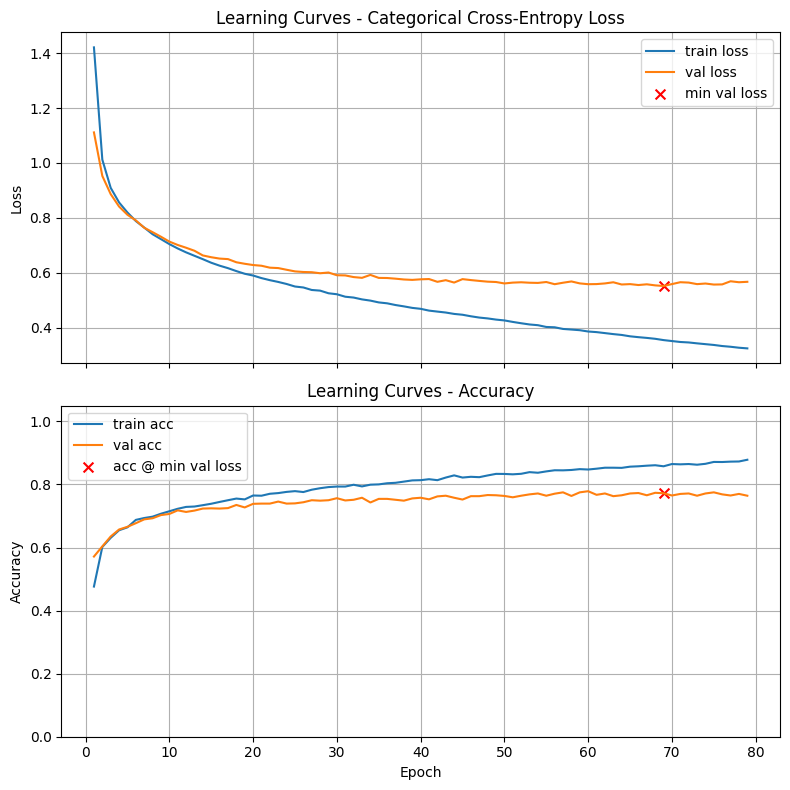

Final Training Loss:            0.3246
Final Training Accuracy:        0.8783
Final Validation Loss:          0.5671
Final Validation Accuracy:      0.7643
Minimum Validation Loss:        0.5519 (Epoch 69)
Validation Accuracy @ Min Loss: 0.7721

Test Loss: 0.5708
Test Accuracy: 0.7679

Validation-Test Gap (accuracy): 0.004286

Execution Time: 00:00:08


In [11]:
model_baseline_tanh = build_model(
    n_inputs=X_train.shape[1], 
    # (width, act, l2_lambda, dropout_rate)
    layer_list=[
        (64, 'tanh', 0.0, 0.0), 
        (32, 'tanh', 0.0, 0.0)
    ], 
    n_classes=n_classes
)
print(model_baseline_tanh.summary())
train_and_test(model=model_baseline_tanh)

### Graded Questions

In [12]:
# Set a1a to the activation function which provided the best validation accuracy at the epoch of minimum validation loss

a1a = 0             # Replace with integer 0 (relu), 1 (sigmoid), or 2 (tanh)

In [13]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a1a = {a1a}') 


a1a = 0


In [14]:
# Set a1b to the validation accuracy found by this best activation function

a1b = 0.7800             # Replace 0.0 with your answer

In [15]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a1b = {a1b:.4f}') 

a1b = 0.7800


### Problem Two: Finding the Right Learning Rate

In this problem, you will continue working with the **baseline model** and determine which learning rate produces the best performance. As before, the model you evaluate should be the one saved by **early stopping** — the epoch where validation loss is minimized.

**Steps to follow:**

* Build and train the **baseline model** using the **activation function identified in Problem One**.

* Train and evaluate this model using each of the following learning rates:

  ```
      [1e-3, 5e-4, 1e-4, 5e-5, 1e-5]
  ```

* Identify which learning rate produces the **best validation accuracy** at the epoch of **minimum validation loss**, within a maximum of **500 epochs**.

* Answer the graded questions.


**Note: Smaller learning rates will generally take more epochs to reach the optimal point, so some of these will not engage early stopping, but run the full 500 epochs.**


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 64)             │         3,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,831 (22.78 KB)

 Trainable params: 5,831 (22.78 KB)

 Non-trainable params: 0 (0.00 B)

None

Learning Curves



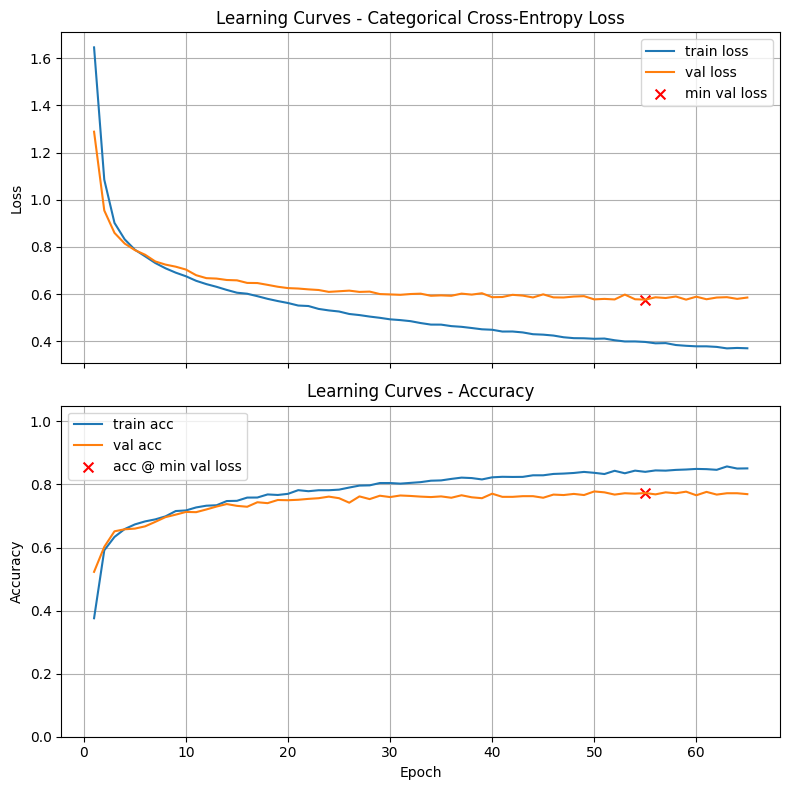

Final Training Loss:            0.3700
Final Training Accuracy:        0.8510
Final Validation Loss:          0.5851
Final Validation Accuracy:      0.7693
Minimum Validation Loss:        0.5763 (Epoch 55)
Validation Accuracy @ Min Loss: 0.7729

Test Loss: 0.6269
Test Accuracy: 0.7657

Validation-Test Gap (accuracy): 0.007143

Execution Time: 00:00:06


In [16]:
model_baseline_relu_lr_1e3 = build_model(
    n_inputs=X_train.shape[1], 
    # (width, act, l2_lambda, dropout_rate)
    layer_list=[
        (64, 'relu', 0.0, 0.0), 
        (32, 'relu', 0.0, 0.0)
    ], 
    n_classes=n_classes
)
print(model_baseline_relu_lr_1e3.summary())
train_and_test(model=model_baseline_relu_lr_1e3, lr_schedule=1e-3)

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 64)             │         3,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,831 (22.78 KB)

 Trainable params: 5,831 (22.78 KB)

 Non-trainable params: 0 (0.00 B)

None

Learning Curves



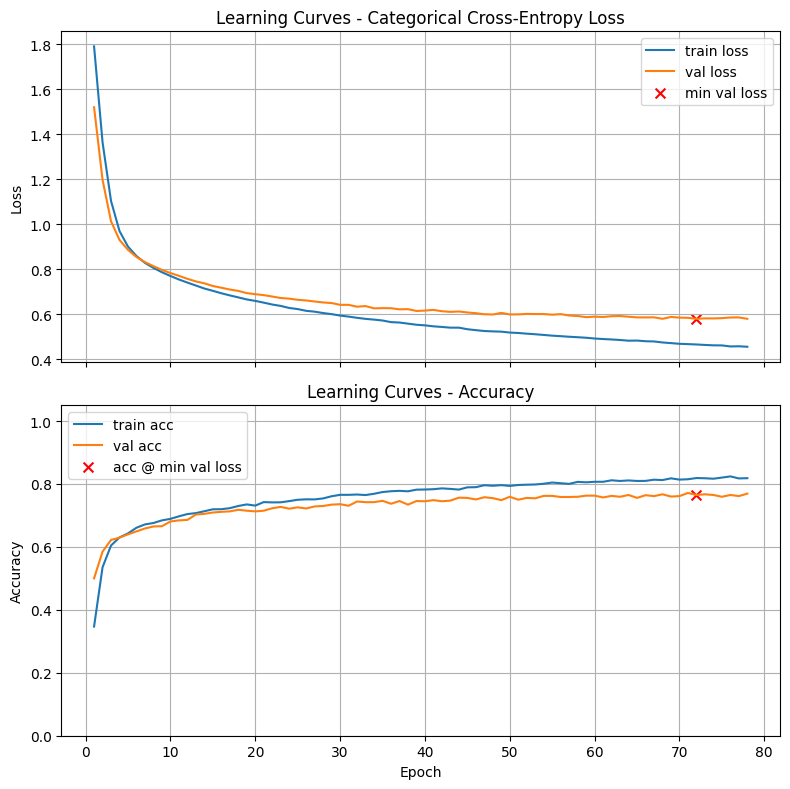

Final Training Loss:            0.4546
Final Training Accuracy:        0.8183
Final Validation Loss:          0.5788
Final Validation Accuracy:      0.7693
Minimum Validation Loss:        0.5788 (Epoch 72)
Validation Accuracy @ Min Loss: 0.7650

Test Loss: 0.6214
Test Accuracy: 0.7586

Validation-Test Gap (accuracy): 0.008571

Execution Time: 00:00:08


In [17]:
model_baseline_relu_lr_5e4 = build_model(
    n_inputs=X_train.shape[1], 
    # (width, act, l2_lambda, dropout_rate)
    layer_list=[
        (64, 'relu', 0.0, 0.0), 
        (32, 'relu', 0.0, 0.0)
    ], 
    n_classes=n_classes
)
print(model_baseline_relu_lr_5e4.summary())
train_and_test(model=model_baseline_relu_lr_5e4, lr_schedule=5e-4)

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 64)             │         3,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,831 (22.78 KB)

 Trainable params: 5,831 (22.78 KB)

 Non-trainable params: 0 (0.00 B)

None

Learning Curves



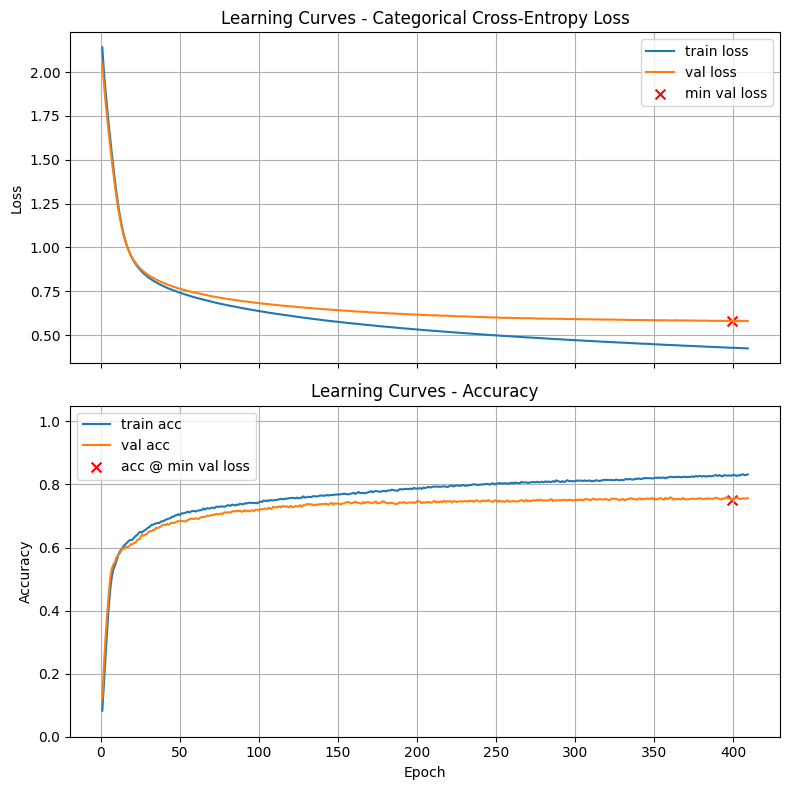

Final Training Loss:            0.4238
Final Training Accuracy:        0.8319
Final Validation Loss:          0.5796
Final Validation Accuracy:      0.7564
Minimum Validation Loss:        0.5792 (Epoch 399)
Validation Accuracy @ Min Loss: 0.7514

Test Loss: 0.6074
Test Accuracy: 0.7629

Validation-Test Gap (accuracy): 0.011429

Execution Time: 00:00:40


In [18]:
model_baseline_relu_lr_1e4 = build_model(
    n_inputs=X_train.shape[1], 
    # (width, act, l2_lambda, dropout_rate)
    layer_list=[
        (64, 'relu', 0.0, 0.0), 
        (32, 'relu', 0.0, 0.0)
    ], 
    n_classes=n_classes
)
print(model_baseline_relu_lr_1e4.summary())
train_and_test(model=model_baseline_relu_lr_1e4, lr_schedule=1e-4)

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 64)             │         3,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,831 (22.78 KB)

 Trainable params: 5,831 (22.78 KB)

 Non-trainable params: 0 (0.00 B)

None

Learning Curves



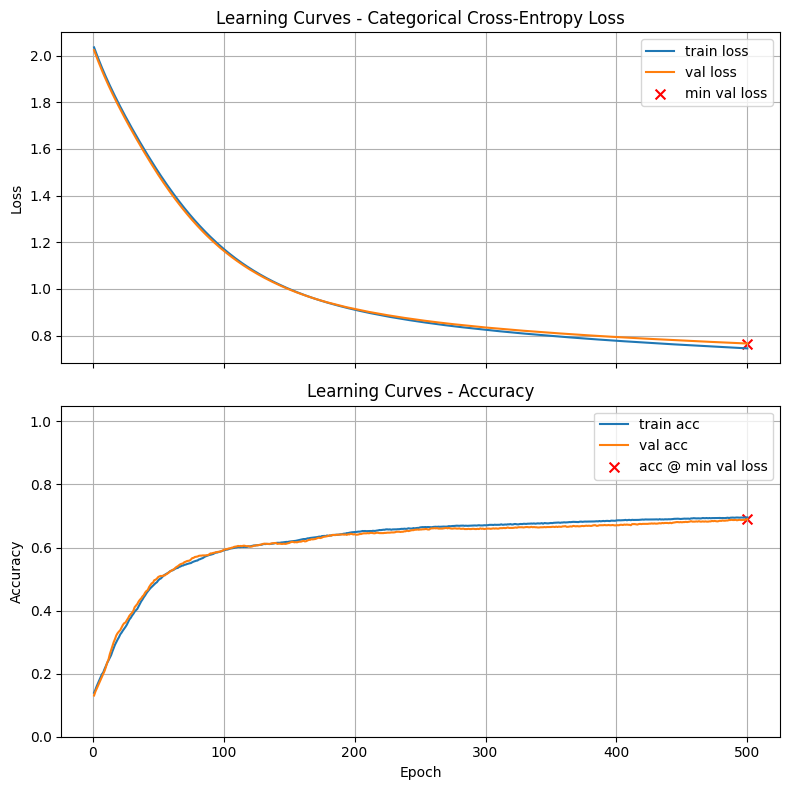

Final Training Loss:            0.7455
Final Training Accuracy:        0.6955
Final Validation Loss:          0.7663
Final Validation Accuracy:      0.6893
Minimum Validation Loss:        0.7663 (Epoch 500)
Validation Accuracy @ Min Loss: 0.6893

Test Loss: 0.7925
Test Accuracy: 0.6736

Validation-Test Gap (accuracy): 0.015714

Execution Time: 00:00:48


In [19]:
model_baseline_relu_lr_1e5 = build_model(
    n_inputs=X_train.shape[1], 
    # (width, act, l2_lambda, dropout_rate)
    layer_list=[
        (64, 'relu', 0.0, 0.0), 
        (32, 'relu', 0.0, 0.0)
    ], 
    n_classes=n_classes
)
print(model_baseline_relu_lr_1e5.summary())
train_and_test(model=model_baseline_relu_lr_1e5, lr_schedule=1e-5)

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_27 (Dense)                │ (None, 64)             │         3,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,831 (22.78 KB)

 Trainable params: 5,831 (22.78 KB)

 Non-trainable params: 0 (0.00 B)

None

Learning Curves



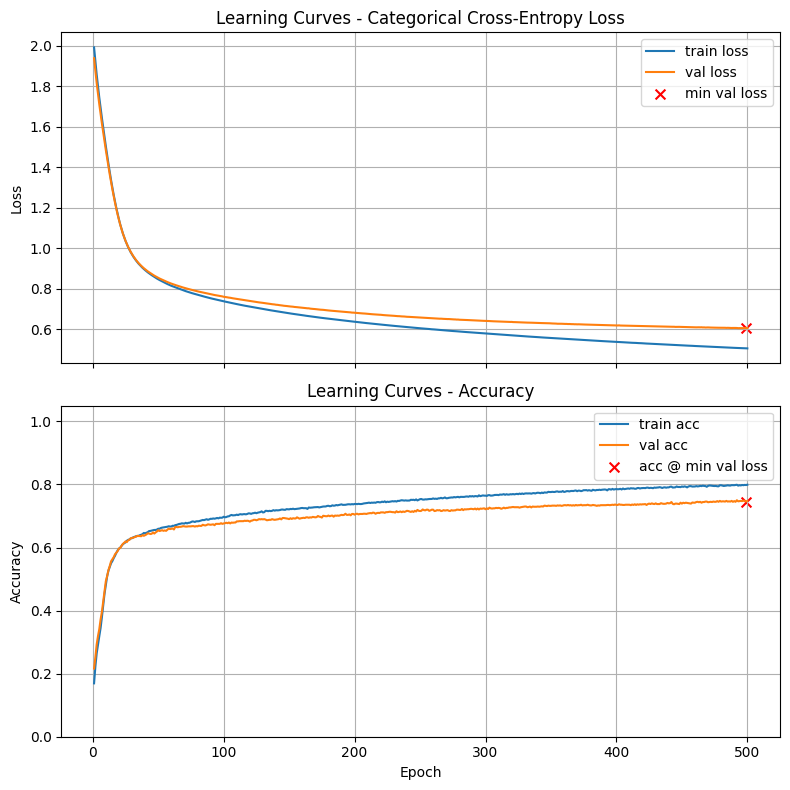

Final Training Loss:            0.5053
Final Training Accuracy:        0.7990
Final Validation Loss:          0.6054
Final Validation Accuracy:      0.7479
Minimum Validation Loss:        0.6049 (Epoch 499)
Validation Accuracy @ Min Loss: 0.7457

Test Loss: 0.6485
Test Accuracy: 0.7364

Validation-Test Gap (accuracy): 0.009286

Execution Time: 00:00:48


In [20]:
model_baseline_relu_lr_5e5 = build_model(
    n_inputs=X_train.shape[1], 
    # (width, act, l2_lambda, dropout_rate)
    layer_list=[
        (64, 'relu', 0.0, 0.0), 
        (32, 'relu', 0.0, 0.0)
    ], 
    n_classes=n_classes
)
print(model_baseline_relu_lr_5e5.summary())
train_and_test(model=model_baseline_relu_lr_5e5, lr_schedule=5e-5)

#### Graded Questions

In [21]:
# Set a2a to the learning rate which provided the best validation accuracy at the epoch of minimum validation loss

a2a = 5e-4           # Replace 0.0 with your answer

In [22]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a2a = {a2a:.6f}') 

a2a = 0.000500


In [23]:
# Set a2b to the validation accuracy found by this best learning rate

a2b = 0.770             # Replace 0.0 with your answer

In [24]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a2b = {a2b:.4f}') 

a2b = 0.7700


### Problem Three: Dropout

In this problem, you will explore how **dropout** can help prevent overfitting in neural networks. There are no absolute rules, but some useful heuristics are:

* Dropout typically works best in **later dense layers** (e.g., the second hidden layer of width 32) in the range **0.3–0.5**.
* If applied to **earlier layers** (e.g., the first hidden layer), dropout should be smaller, typically **0.0–0.2** (where 0.0 means no dropout).

**Steps to follow:**

* Build and train the **baseline model** using the **activation function from Problem One** and the **learning rate from Problem Two**.
* Investigate dropout in the ranges suggested, using increments of **0.1**.
* Identify which dropout configuration produces the **best validation accuracy** at the epoch of **minimum validation loss**.
* Answer the graded questions.


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_30 (Dense)                │ (None, 64)             │         3,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,831 (22.78 KB)

 Trainable params: 5,831 (22.78 KB)

 Non-trainable params: 0 (0.00 B)

None

Learning Curves



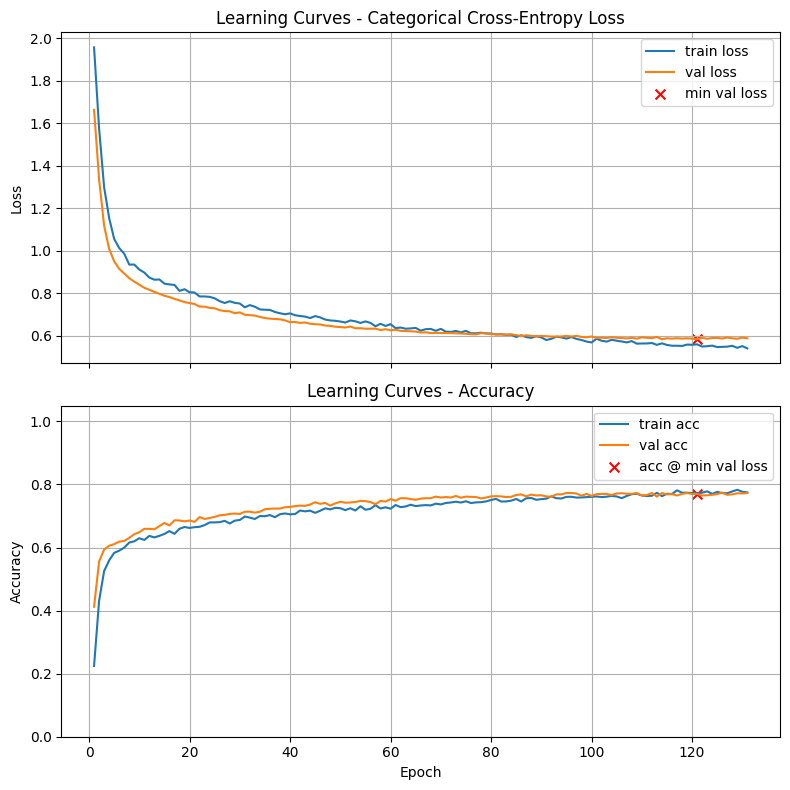

Final Training Loss:            0.5395
Final Training Accuracy:        0.7748
Final Validation Loss:          0.5869
Final Validation Accuracy:      0.7729
Minimum Validation Loss:        0.5823 (Epoch 121)
Validation Accuracy @ Min Loss: 0.7700

Test Loss: 0.6008
Test Accuracy: 0.7543

Validation-Test Gap (accuracy): 0.015714

Execution Time: 00:00:13


In [25]:
model_baseline_relu_lr_5e4_dr_3_0 = build_model(
    n_inputs=X_train.shape[1], 
    # (width, act, l2_lambda, dropout_rate)
    layer_list=[
        (64, 'relu', 0.0, 0.3), 
        (32, 'relu', 0.0, 0.0)
    ], 
    n_classes=n_classes
)
print(model_baseline_relu_lr_5e4_dr_3_0.summary())
train_and_test(model=model_baseline_relu_lr_5e4_dr_3_0, lr_schedule=5e-4)

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_33 (Dense)                │ (None, 64)             │         3,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,831 (22.78 KB)

 Trainable params: 5,831 (22.78 KB)

 Non-trainable params: 0 (0.00 B)

None

Learning Curves



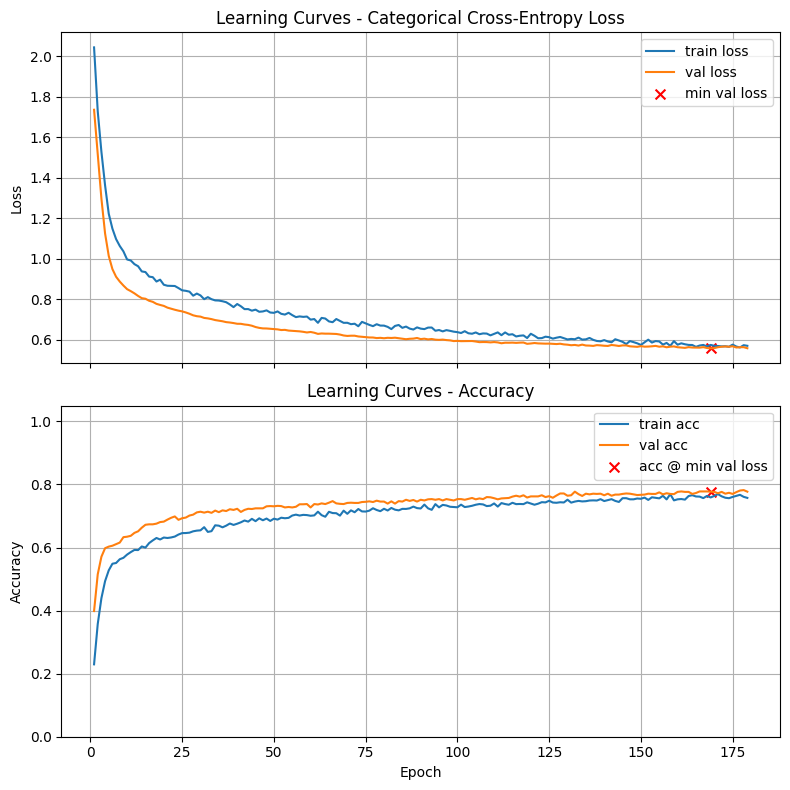

Final Training Loss:            0.5713
Final Training Accuracy:        0.7574
Final Validation Loss:          0.5593
Final Validation Accuracy:      0.7771
Minimum Validation Loss:        0.5586 (Epoch 169)
Validation Accuracy @ Min Loss: 0.7771

Test Loss: 0.5904
Test Accuracy: 0.7650

Validation-Test Gap (accuracy): 0.012143

Execution Time: 00:00:18


In [26]:
model_baseline_relu_lr_5e4_dr_4_1 = build_model(
    n_inputs=X_train.shape[1], 
    # (width, act, l2_lambda, dropout_rate)
    layer_list=[
        (64, 'relu', 0.0, 0.4), 
        (32, 'relu', 0.0, 0.1)
    ], 
    n_classes=n_classes
)
print(model_baseline_relu_lr_5e4_dr_4_1.summary())
train_and_test(model=model_baseline_relu_lr_5e4_dr_4_1, lr_schedule=5e-4)

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_36 (Dense)                │ (None, 64)             │         3,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,831 (22.78 KB)

 Trainable params: 5,831 (22.78 KB)

 Non-trainable params: 0 (0.00 B)

None

Learning Curves



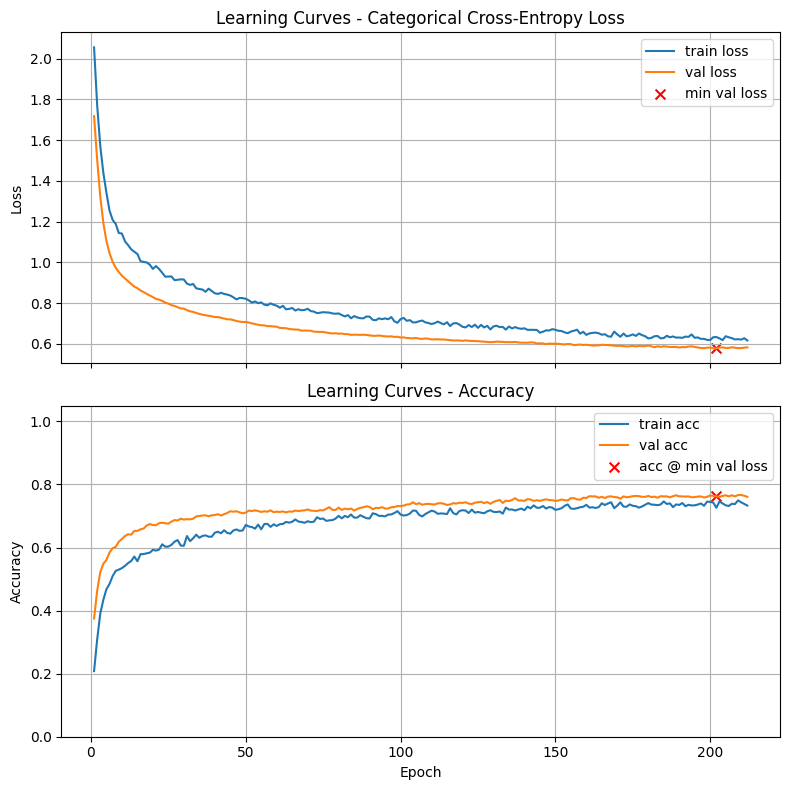

Final Training Loss:            0.6164
Final Training Accuracy:        0.7331
Final Validation Loss:          0.5823
Final Validation Accuracy:      0.7607
Minimum Validation Loss:        0.5772 (Epoch 202)
Validation Accuracy @ Min Loss: 0.7621

Test Loss: 0.6138
Test Accuracy: 0.7436

Validation-Test Gap (accuracy): 0.018571

Execution Time: 00:00:21


In [27]:
model_baseline_relu_lr_5e4_dr_5_2 = build_model(
    n_inputs=X_train.shape[1], 
    # (width, act, l2_lambda, dropout_rate)
    layer_list=[
        (64, 'relu', 0.0, 0.5), 
        (32, 'relu', 0.0, 0.2)
    ], 
    n_classes=n_classes
)
print(model_baseline_relu_lr_5e4_dr_5_2.summary())
train_and_test(model=model_baseline_relu_lr_5e4_dr_5_2, lr_schedule=5e-4)

In [28]:
# Set a3a to the pair (dropout_rate_64,dropout_rate_32) of dropout rates for the two hidden layers which provided the best 
# validation accuracy at the epoch of minimum validation loss

a3a = (0.4,0.1)             # Replace (0.0,0.0) with your answer

In [29]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a3a = {a3a}') 

a3a = (0.4, 0.1)


In [30]:
# Set a3b to the validation accuracy found by this best pair of dropout rates

a3b = 0.7864             # Replace 0.0 with your answer

In [31]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a3b = {a3b:.4f}') 

a3b = 0.7864


### Problem Four: L2 Regularization

In this problem, you will explore how **L2 regularization** (also called *weight decay*) can help prevent overfitting in neural networks. There are no absolute rules, but some useful heuristics are:

* Start simply by using the **same λ in both hidden layers**, with values:

  ```
      1e-4, 1e-3, 1e-2
  ```

* If validation results suggest underfitting in the first layer or persistent overfitting in the later one, then try adjusting per layer, for example:

  * First hidden layer: λ = 1e-4
  * Second hidden layer: λ = 1e-3

**Steps to follow:**

* Build and train the **baseline model** using the **activation function from Problem One** and the **learning rate from Problem Two**, but **without dropout**.
* Investigate at least the four cases suggested (three with the same λ and one with different λ values). You may also consider additional combinations.
* Identify which configuration produces the **best validation accuracy** at the epoch of **minimum validation loss**.
* Answer the graded questions.


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_39 (Dense)                │ (None, 64)             │         3,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,831 (22.78 KB)

 Trainable params: 5,831 (22.78 KB)

 Non-trainable params: 0 (0.00 B)

None

Learning Curves



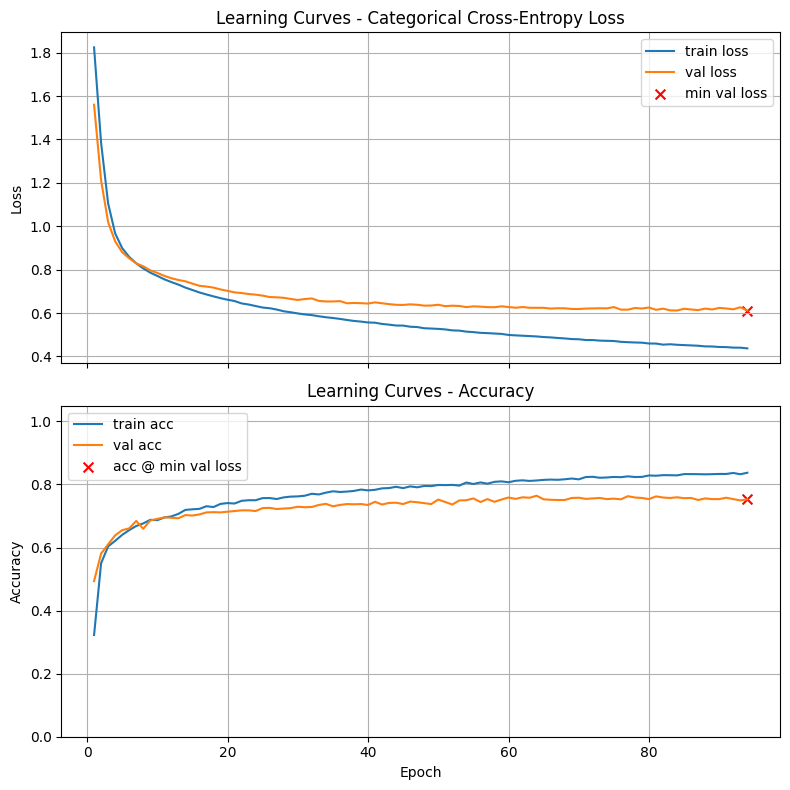

Final Training Loss:            0.4373
Final Training Accuracy:        0.8371
Final Validation Loss:          0.6118
Final Validation Accuracy:      0.7529
Minimum Validation Loss:        0.6118 (Epoch 94)
Validation Accuracy @ Min Loss: 0.7529

Test Loss: 0.6177
Test Accuracy: 0.7529

Validation-Test Gap (accuracy): 0.006429

Execution Time: 00:00:09


In [32]:
model_baseline_relu_lr_5e4_reg_1e4 = build_model(
    n_inputs=X_train.shape[1], 
    # (width, act, l2_lambda, dropout_rate)
    layer_list=[
        (64, 'relu', 1e-4, 0.0), 
        (32, 'relu', 1e-4, 0.0)
    ], 
    n_classes=n_classes
)
print(model_baseline_relu_lr_5e4_reg_1e4.summary())
train_and_test(model=model_baseline_relu_lr_5e4_reg_1e4, lr_schedule=5e-4)

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_42 (Dense)                │ (None, 64)             │         3,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,831 (22.78 KB)

 Trainable params: 5,831 (22.78 KB)

 Non-trainable params: 0 (0.00 B)

None

Learning Curves



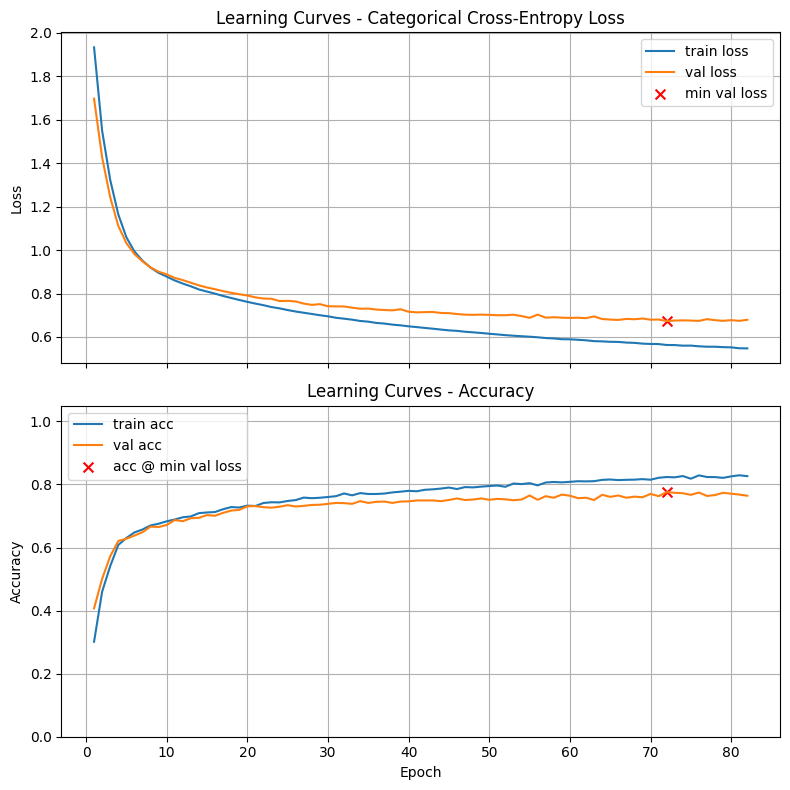

Final Training Loss:            0.5475
Final Training Accuracy:        0.8264
Final Validation Loss:          0.6792
Final Validation Accuracy:      0.7643
Minimum Validation Loss:        0.6733 (Epoch 72)
Validation Accuracy @ Min Loss: 0.7757

Test Loss: 0.6821
Test Accuracy: 0.7607

Validation-Test Gap (accuracy): 0.015000

Execution Time: 00:00:09


In [33]:
model_baseline_relu_lr_5e4_reg_1e3 = build_model(
    n_inputs=X_train.shape[1], 
    # (width, act, l2_lambda, dropout_rate)
    layer_list=[
        (64, 'relu', 1e-3, 0.0), 
        (32, 'relu', 1e-3, 0.0)
    ], 
    n_classes=n_classes
)
print(model_baseline_relu_lr_5e4_reg_1e3.summary())
train_and_test(model=model_baseline_relu_lr_5e4_reg_1e3, lr_schedule=5e-4)

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_45 (Dense)                │ (None, 64)             │         3,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,831 (22.78 KB)

 Trainable params: 5,831 (22.78 KB)

 Non-trainable params: 0 (0.00 B)

None

Learning Curves



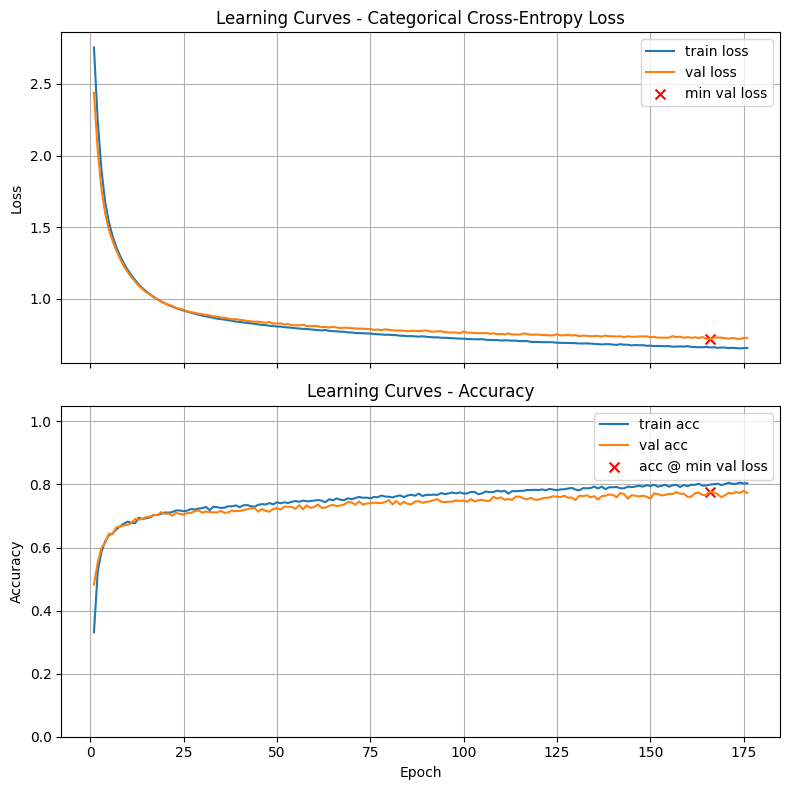

Final Training Loss:            0.6583
Final Training Accuracy:        0.8040
Final Validation Loss:          0.7291
Final Validation Accuracy:      0.7729
Minimum Validation Loss:        0.7189 (Epoch 166)
Validation Accuracy @ Min Loss: 0.7771

Test Loss: 0.7442
Test Accuracy: 0.7579

Validation-Test Gap (accuracy): 0.019286

Execution Time: 00:00:17


In [34]:
model_baseline_relu_lr_5e4_reg_1e2 = build_model(
    n_inputs=X_train.shape[1], 
    # (width, act, l2_lambda, dropout_rate)
    layer_list=[
        (64, 'relu', 1e-2, 0.0), 
        (32, 'relu', 1e-2, 0.0)
    ], 
    n_classes=n_classes
)
print(model_baseline_relu_lr_5e4_reg_1e2.summary())
train_and_test(model=model_baseline_relu_lr_5e4_reg_1e2, lr_schedule=5e-4)

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_48 (Dense)                │ (None, 64)             │         3,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,831 (22.78 KB)

 Trainable params: 5,831 (22.78 KB)

 Non-trainable params: 0 (0.00 B)

None

Learning Curves



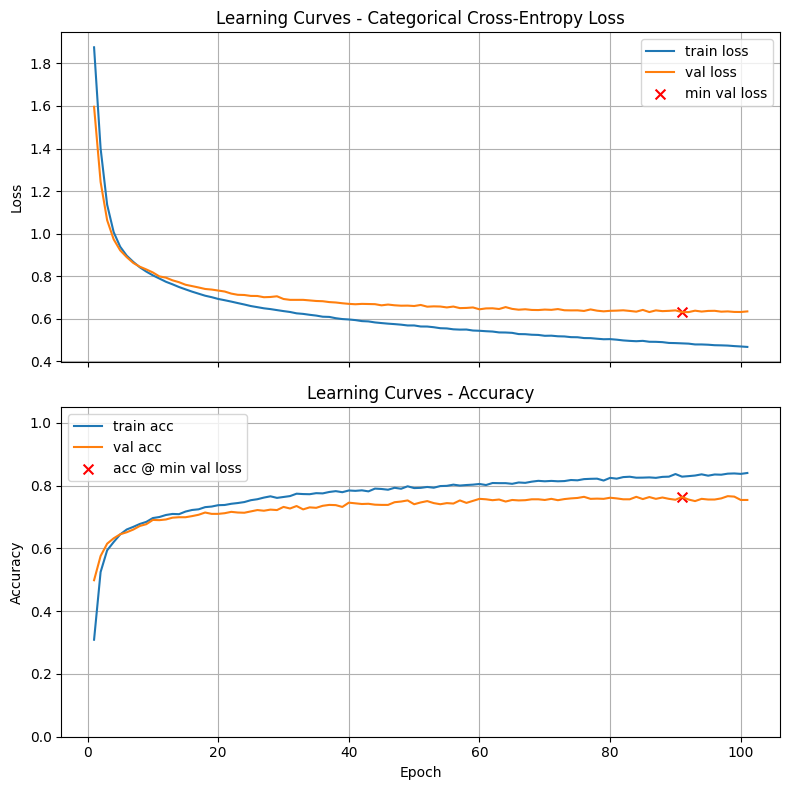

Final Training Loss:            0.4672
Final Training Accuracy:        0.8402
Final Validation Loss:          0.6342
Final Validation Accuracy:      0.7543
Minimum Validation Loss:        0.6308 (Epoch 91)
Validation Accuracy @ Min Loss: 0.7636

Test Loss: 0.6338
Test Accuracy: 0.7529

Validation-Test Gap (accuracy): 0.010714

Execution Time: 00:00:10


In [35]:
model_baseline_relu_lr_5e4_reg_mixed_1e4_1e3 = build_model(
    n_inputs=X_train.shape[1], 
    # (width, act, l2_lambda, dropout_rate)
    layer_list=[
        (64, 'relu', 1e-4, 0.0), 
        (32, 'relu', 1e-3, 0.0)
    ], 
    n_classes=n_classes
)
print(model_baseline_relu_lr_5e4_reg_mixed_1e4_1e3.summary())
train_and_test(model=model_baseline_relu_lr_5e4_reg_mixed_1e4_1e3, lr_schedule=5e-4)

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_51 (Dense)                │ (None, 64)             │         3,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,831 (22.78 KB)

 Trainable params: 5,831 (22.78 KB)

 Non-trainable params: 0 (0.00 B)

None

Learning Curves



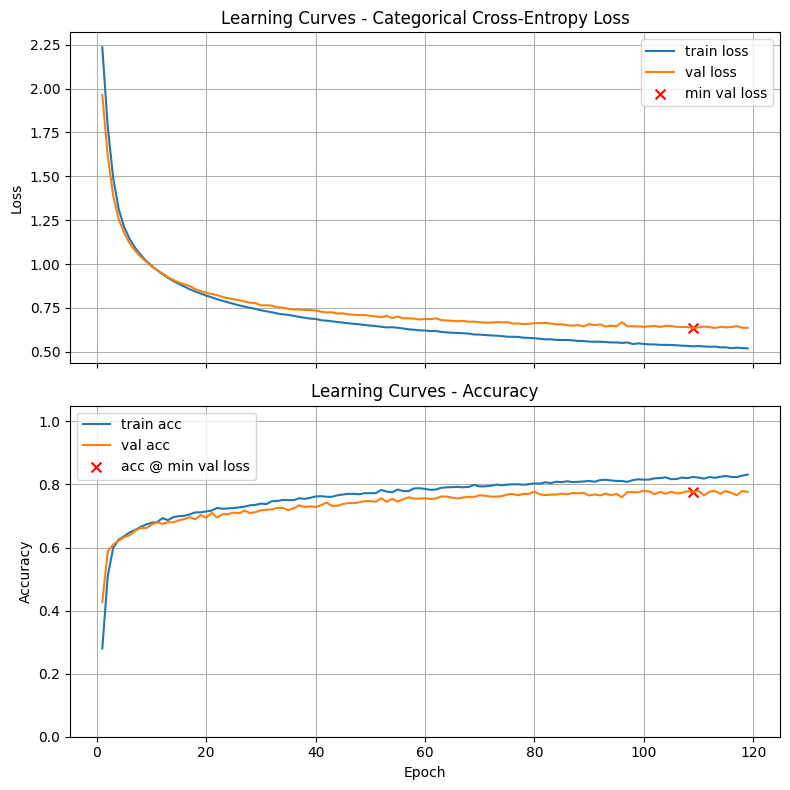

Final Training Loss:            0.5198
Final Training Accuracy:        0.8314
Final Validation Loss:          0.6367
Final Validation Accuracy:      0.7764
Minimum Validation Loss:        0.6340 (Epoch 109)
Validation Accuracy @ Min Loss: 0.7750

Test Loss: 0.6631
Test Accuracy: 0.7550

Validation-Test Gap (accuracy): 0.020000

Execution Time: 00:00:11


In [36]:
model_baseline_relu_lr_5e4_reg_mixed_1e4_1e2 = build_model(
    n_inputs=X_train.shape[1], 
    # (width, act, l2_lambda, dropout_rate)
    layer_list=[
        (64, 'relu', 1e-4, 0.0), 
        (32, 'relu', 1e-2, 0.0)
    ], 
    n_classes=n_classes
)
print(model_baseline_relu_lr_5e4_reg_mixed_1e4_1e2.summary())
train_and_test(model=model_baseline_relu_lr_5e4_reg_mixed_1e4_1e2, lr_schedule=5e-4)

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_54 (Dense)                │ (None, 64)             │         3,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_56 (Dense)                │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,831 (22.78 KB)

 Trainable params: 5,831 (22.78 KB)

 Non-trainable params: 0 (0.00 B)

None

Learning Curves



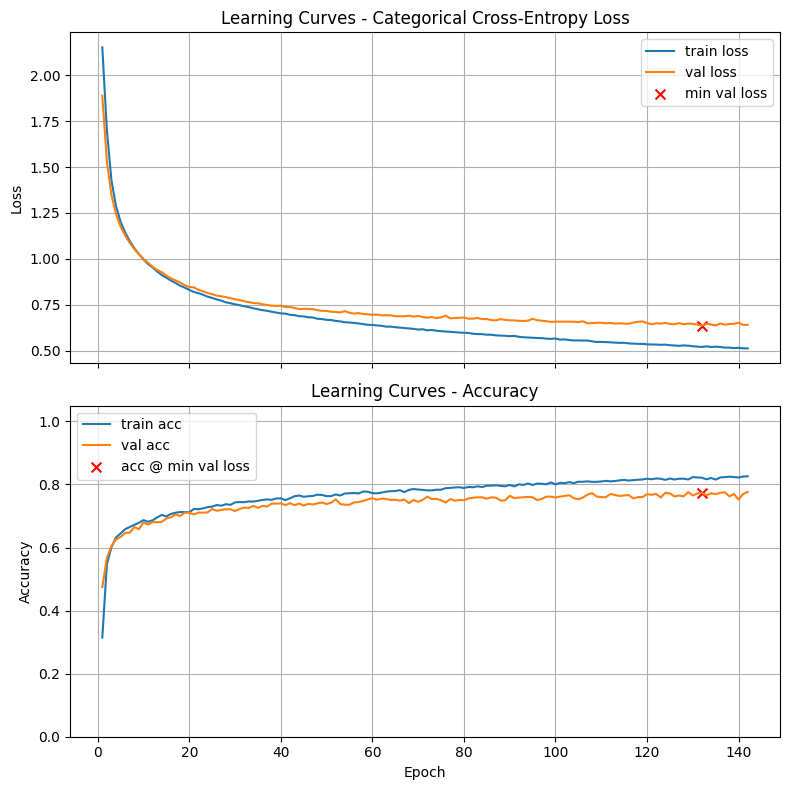

Final Training Loss:            0.5116
Final Training Accuracy:        0.8257
Final Validation Loss:          0.6398
Final Validation Accuracy:      0.7764
Minimum Validation Loss:        0.6356 (Epoch 132)
Validation Accuracy @ Min Loss: 0.7729

Test Loss: 0.6532
Test Accuracy: 0.7643

Validation-Test Gap (accuracy): 0.008571

Execution Time: 00:00:14


In [37]:
model_baseline_relu_lr_5e4_reg_mixed_1e4_1e2 = build_model(
    n_inputs=X_train.shape[1], 
    # (width, act, l2_lambda, dropout_rate)
    layer_list=[
        (64, 'relu', 1e-4, 0.0), 
        (32, 'relu', 1e-2, 0.0)
    ], 
    n_classes=n_classes
)
print(model_baseline_relu_lr_5e4_reg_mixed_1e4_1e2.summary())
train_and_test(model=model_baseline_relu_lr_5e4_reg_mixed_1e4_1e2, lr_schedule=5e-4)

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_57 (Dense)                │ (None, 64)             │         3,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_59 (Dense)                │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,831 (22.78 KB)

 Trainable params: 5,831 (22.78 KB)

 Non-trainable params: 0 (0.00 B)

None

Learning Curves



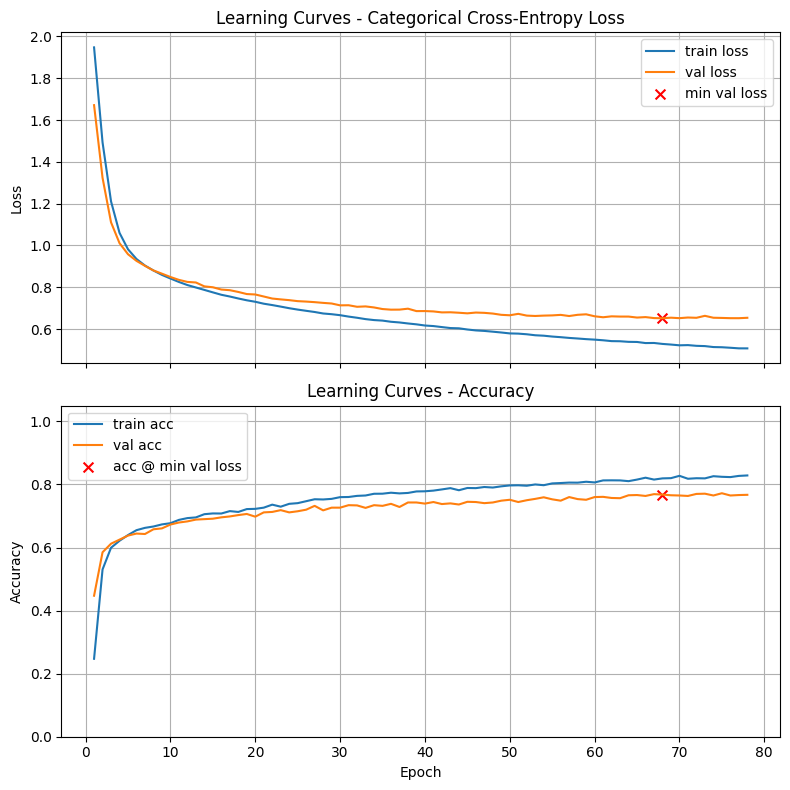

Final Training Loss:            0.5075
Final Training Accuracy:        0.8286
Final Validation Loss:          0.6538
Final Validation Accuracy:      0.7671
Minimum Validation Loss:        0.6516 (Epoch 68)
Validation Accuracy @ Min Loss: 0.7679

Test Loss: 0.6544
Test Accuracy: 0.7557

Validation-Test Gap (accuracy): 0.012143

Execution Time: 00:00:08


In [38]:
model_baseline_relu_lr_5e4_reg_mixed_1e3_1e4 = build_model(
    n_inputs=X_train.shape[1], 
    # (width, act, l2_lambda, dropout_rate)
    layer_list=[
        (64, 'relu', 1e-3, 0.0), 
        (32, 'relu', 1e-4, 0.0)
    ], 
    n_classes=n_classes
)
print(model_baseline_relu_lr_5e4_reg_mixed_1e3_1e4.summary())
train_and_test(model=model_baseline_relu_lr_5e4_reg_mixed_1e3_1e4, lr_schedule=5e-4)

In [39]:
# Set a4a to the pair (L2_lambda_64,L2_lambda_32) of the L2 lambdas for the two hidden layers which provided the best 
# validation accuracy at the epoch of minimum validation loss

a4a = (1e-4,1e-2)             # Replace (0.0,0.0) with your answer

In [40]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a4a = {a4a}') 

a4a = (0.0001, 0.01)


In [41]:
# Set a4b to the validation accuracy found by this best pair of lambdas

a4b = 0.7879             # Replace 0.0 with your answer

In [42]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a4b = {a4b:.4f}') 

a4b = 0.7879


### Problem Five: Combining Dropout with L2 Regularization

In this problem, you will explore how **dropout** and **L2 regularization** can work together to prevent overfitting. These two methods complement each other, but must be balanced carefully. A useful rule of thumb is:

* If dropout is **high**, use a **smaller λ**.
* If dropout is **low**, you can afford a **larger λ**.

**Steps to follow:**

* Build and train the **baseline model** using the **activation function from Problem One** and the **learning rate from Problem Two**.
* Investigate combinations of dropout and L2:

  * First, use the **dropout rate you identified in Problem Three** as a baseline.
  * Then, add L2 to both hidden layers with values:

    ```
        1e-4, 1e-3, 1e-2
    ```

    while keeping dropout fixed.
  * Finally, try **reducing dropout slightly** when L2 is added to see if performance improves.
  * [Optional] You may wish to investigate other combinations not covered here; for example, promising but not optimal choices of dropout rates may provide overall better performance when combines with L2 Regulari 
* Identify which combination produces the **best validation accuracy** at the epoch of **minimum validation loss**.
* Answer the graded questions.



Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_60 (Dense)                │ (None, 64)             │         3,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_61 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_62 (Dense)                │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,831 (22.78 KB)

 Trainable params: 5,831 (22.78 KB)

 Non-trainable params: 0 (0.00 B)

None

Learning Curves



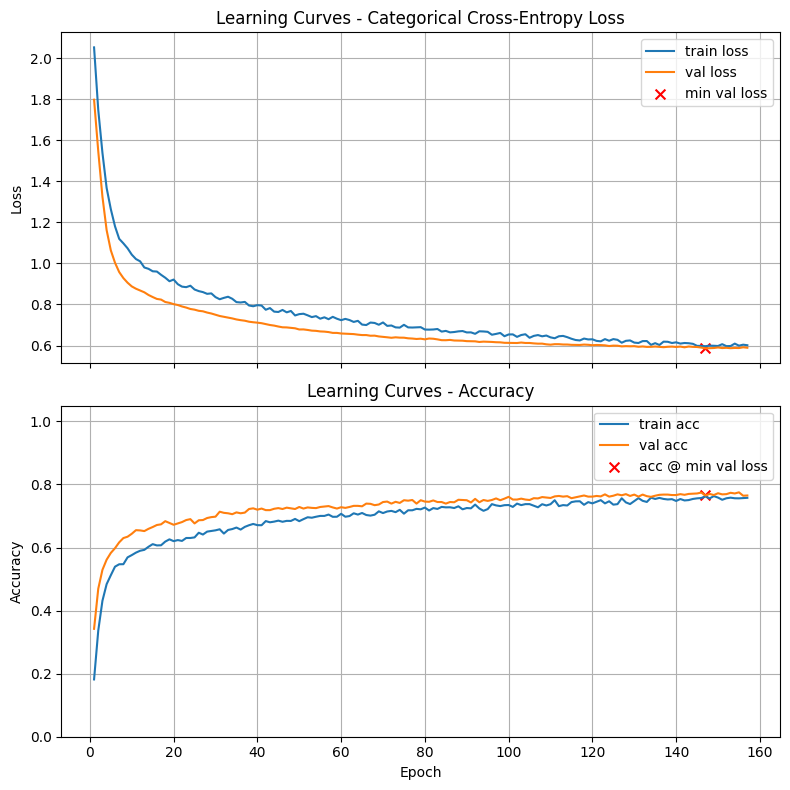

Final Training Loss:            0.6013
Final Training Accuracy:        0.7576
Final Validation Loss:          0.5891
Final Validation Accuracy:      0.7650
Minimum Validation Loss:        0.5860 (Epoch 147)
Validation Accuracy @ Min Loss: 0.7650

Test Loss: 0.6100
Test Accuracy: 0.7636

Validation-Test Gap (accuracy): 0.001429

Execution Time: 00:00:16


In [43]:
model_baseline_relu_lr_5e4_l2_1e4_dr_4_2 = build_model(
    n_inputs=X_train.shape[1], 
    # (width, act, l2_lambda, dropout_rate)
    layer_list=[
        (64, 'relu', 1e-4, 0.4),
        (32, 'relu', 1e-4, 0.1)
    ], 
    n_classes=n_classes
)
print(model_baseline_relu_lr_5e4_l2_1e4_dr_4_2.summary())
train_and_test(model=model_baseline_relu_lr_5e4_l2_1e4_dr_4_2, lr_schedule=5e-4)

Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_63 (Dense)                │ (None, 64)             │         3,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_65 (Dense)                │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,831 (22.78 KB)

 Trainable params: 5,831 (22.78 KB)

 Non-trainable params: 0 (0.00 B)

None

Learning Curves



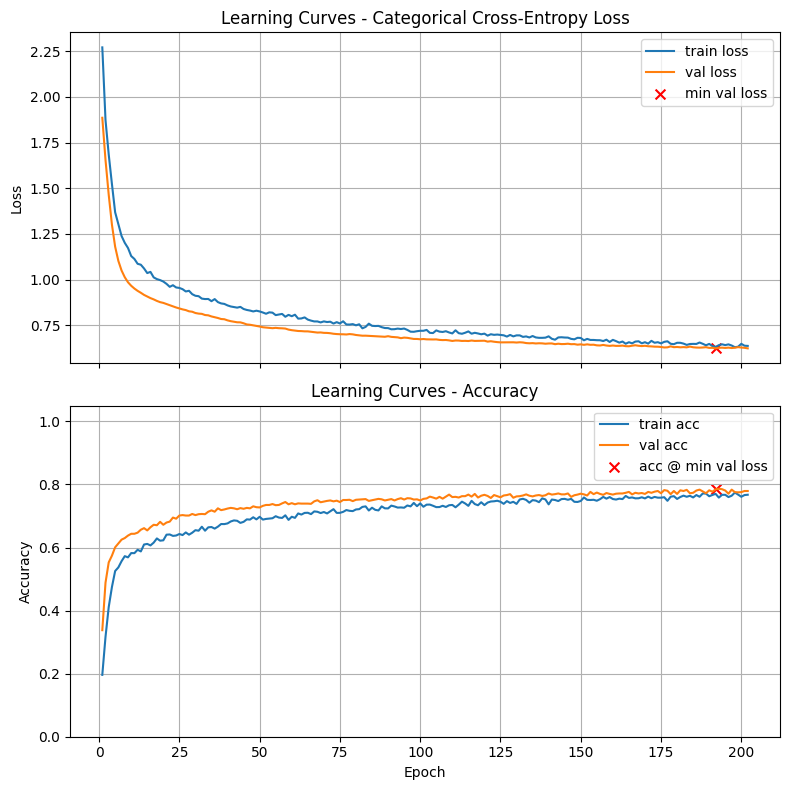

Final Training Loss:            0.6364
Final Training Accuracy:        0.7674
Final Validation Loss:          0.6230
Final Validation Accuracy:      0.7793
Minimum Validation Loss:        0.6229 (Epoch 192)
Validation Accuracy @ Min Loss: 0.7843

Test Loss: 0.6534
Test Accuracy: 0.7607

Validation-Test Gap (accuracy): 0.023571

Execution Time: 00:00:20


In [44]:
model_baseline_relu_lr_5e4_l2_1e3_dr_4_2 = build_model(
    n_inputs=X_train.shape[1], 
    # (width, act, l2_lambda, dropout_rate)
    layer_list=[
        (64, 'relu', 1e-3, 0.4),
        (32, 'relu', 1e-3, 0.1)
    ], 
    n_classes=n_classes
)
print(model_baseline_relu_lr_5e4_l2_1e3_dr_4_2.summary())
train_and_test(model=model_baseline_relu_lr_5e4_l2_1e3_dr_4_2, lr_schedule=5e-4)

Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_66 (Dense)                │ (None, 64)             │         3,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_67 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_68 (Dense)                │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,831 (22.78 KB)

 Trainable params: 5,831 (22.78 KB)

 Non-trainable params: 0 (0.00 B)

None

Learning Curves



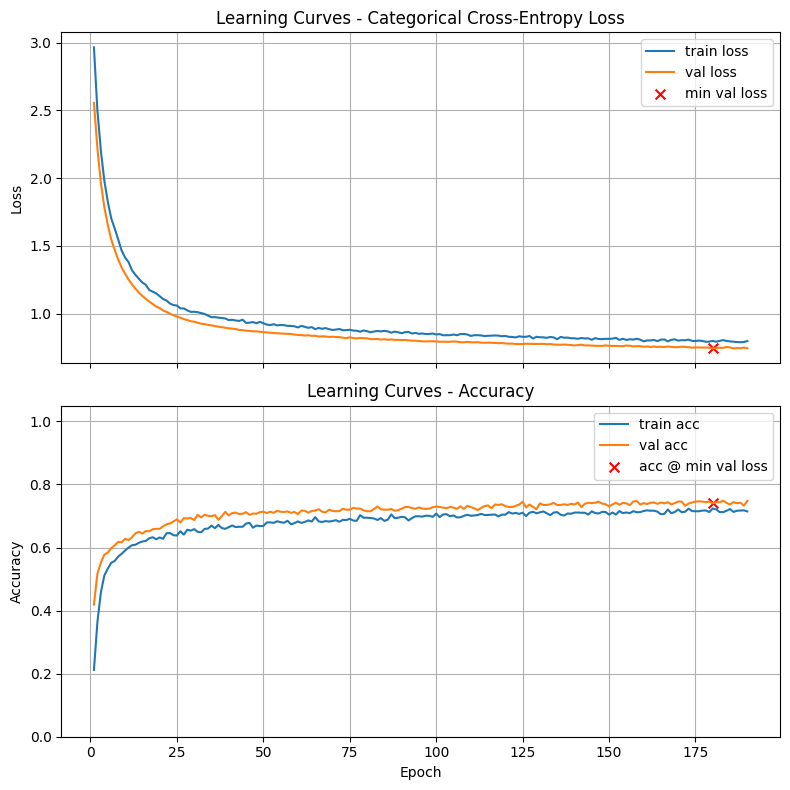

Final Training Loss:            0.7987
Final Training Accuracy:        0.7145
Final Validation Loss:          0.7453
Final Validation Accuracy:      0.7479
Minimum Validation Loss:        0.7446 (Epoch 180)
Validation Accuracy @ Min Loss: 0.7400

Test Loss: 0.7673
Test Accuracy: 0.7321

Validation-Test Gap (accuracy): 0.007857

Execution Time: 00:00:19


In [45]:
model_baseline_relu_lr_5e4_l2_1e2_dr_4_2 = build_model(
    n_inputs=X_train.shape[1], 
    # (width, act, l2_lambda, dropout_rate)
    layer_list=[
        (64, 'relu', 1e-2, 0.4),
        (32, 'relu', 1e-2, 0.1)
    ], 
    n_classes=n_classes
)
print(model_baseline_relu_lr_5e4_l2_1e2_dr_4_2.summary())
train_and_test(model=model_baseline_relu_lr_5e4_l2_1e2_dr_4_2, lr_schedule=5e-4)

Model: "sequential_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_69 (Dense)                │ (None, 64)             │         3,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_70 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_71 (Dense)                │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,831 (22.78 KB)

 Trainable params: 5,831 (22.78 KB)

 Non-trainable params: 0 (0.00 B)

None

Learning Curves



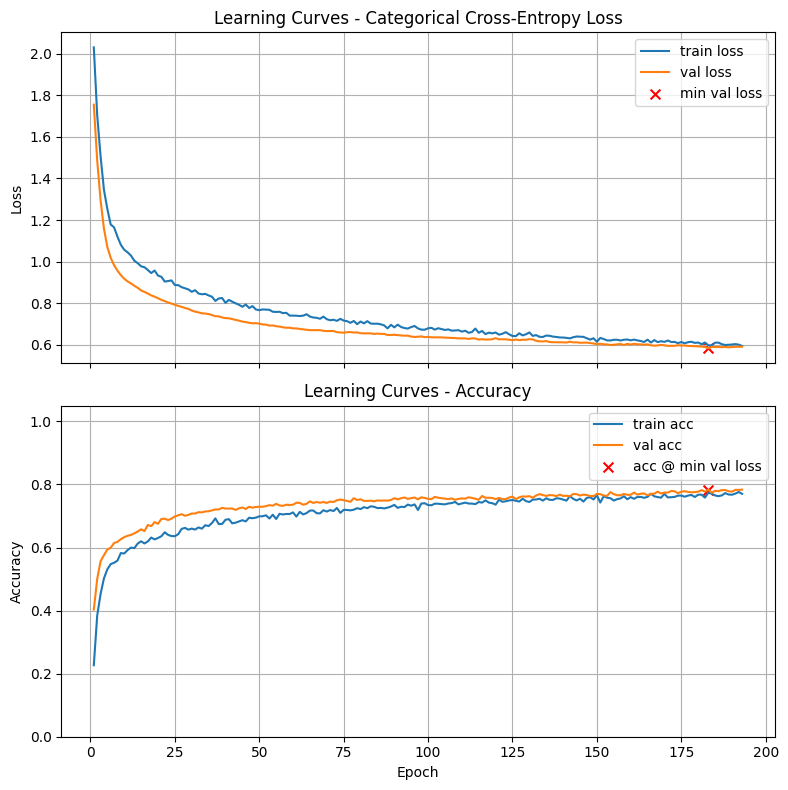

Final Training Loss:            0.5947
Final Training Accuracy:        0.7702
Final Validation Loss:          0.5913
Final Validation Accuracy:      0.7836
Minimum Validation Loss:        0.5834 (Epoch 183)
Validation Accuracy @ Min Loss: 0.7836

Test Loss: 0.6390
Test Accuracy: 0.7636

Validation-Test Gap (accuracy): 0.020000

Execution Time: 00:00:19


In [46]:
model_baseline_relu_lr_5e4_l2_1e34_dr_4_2 = build_model(
    n_inputs=X_train.shape[1], 
    # (width, act, l2_lambda, dropout_rate)
    layer_list=[
        (64, 'relu', 1e-3, 0.4),
        (32, 'relu', 1e-4, 0.1)
    ], 
    n_classes=n_classes
)
print(model_baseline_relu_lr_5e4_l2_1e34_dr_4_2.summary())
train_and_test(model=model_baseline_relu_lr_5e4_l2_1e34_dr_4_2, lr_schedule=5e-4)

Model: "sequential_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_72 (Dense)                │ (None, 64)             │         3,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_73 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_74 (Dense)                │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,831 (22.78 KB)

 Trainable params: 5,831 (22.78 KB)

 Non-trainable params: 0 (0.00 B)

None

Learning Curves



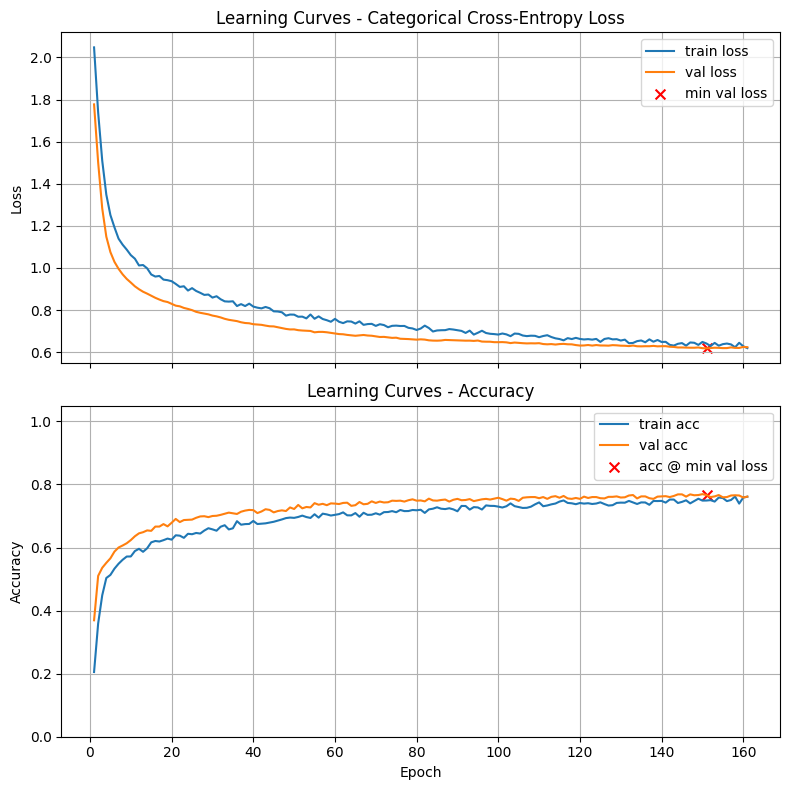

Final Training Loss:            0.6192
Final Training Accuracy:        0.7612
Final Validation Loss:          0.6235
Final Validation Accuracy:      0.7614
Minimum Validation Loss:        0.6178 (Epoch 151)
Validation Accuracy @ Min Loss: 0.7664

Test Loss: 0.6428
Test Accuracy: 0.7529

Validation-Test Gap (accuracy): 0.013571

Execution Time: 00:00:16


In [47]:
model_baseline_relu_lr_5e4_l2_1e43_dr_4_2 = build_model(
    n_inputs=X_train.shape[1], 
    # (width, act, l2_lambda, dropout_rate)
    layer_list=[
        (64, 'relu', 1e-4, 0.4),
        (32, 'relu', 1e-3, 0.1)
    ], 
    n_classes=n_classes
)
print(model_baseline_relu_lr_5e4_l2_1e43_dr_4_2.summary())
train_and_test(model=model_baseline_relu_lr_5e4_l2_1e43_dr_4_2, lr_schedule=5e-4)

In [48]:
# Set a5 to the validation accuracy found by this best combination of dropout and L2 regularization

a5 = 0.7871             # Replace 0.0 with your answer

In [49]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a5 = {a5:.4f}') 

a5 = 0.7871


### Problem Six: Build and Train Your Best Model

In this final problem, you will design and train your **best-performing model** using the techniques explored in the previous problems. You may make your own choices for:

* **Model architecture** (number of layers, widths, etc.)
* **Learning rate**
* **Batch size** (a new hyperparameter not varied in earlier problems)
* **Dropout rates** in both layers
* **L2 λ values** in both layers
* **[Optional but strongly suggested]:** Learning rate scheduling, using either **Exponential Decay** or **Cosine Decay**.

  * For Exponential Decay, typical decay rates are **0.90–0.999**, with **0.95** often a good starting point.

**Steps to follow:**

* Build and train the model according to your design choices.
* Use early stopping as before to evaluate performance at the epoch of **minimum validation loss**.
* Answer the graded question.


Model: "sequential_130"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_390 (Dense)               │ (None, 64)             │         3,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_118 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_391 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_119 (Dropout)           │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_392 (Dense)               │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,831 (22.78 KB)

 Trainable params: 5,831 (22.78 KB)

 Non-trainable params: 0 (0.00 B)

None

Learning Curves



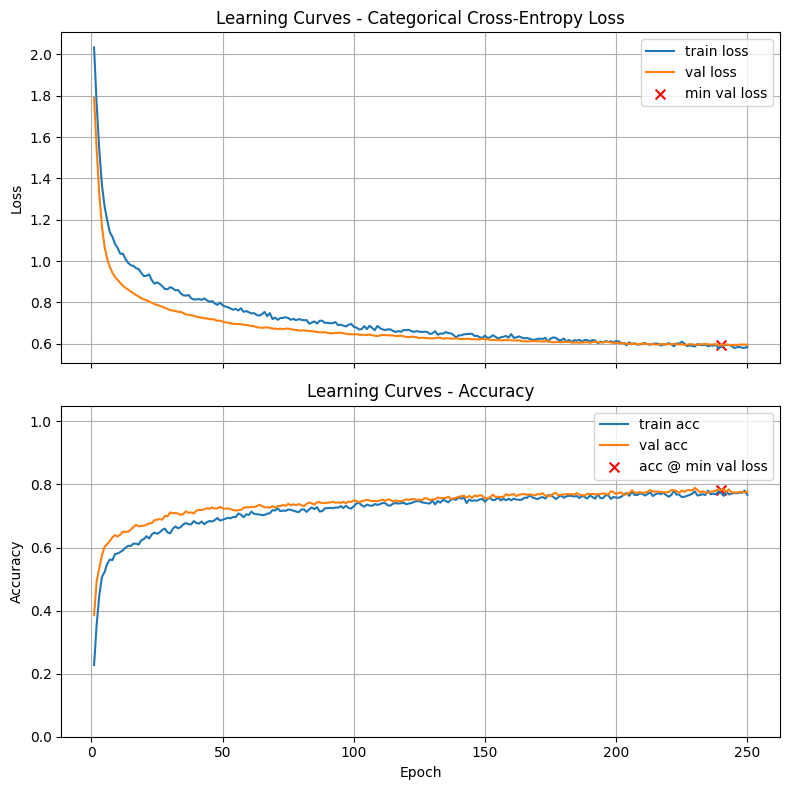

Final Training Loss:            0.5842
Final Training Accuracy:        0.7671
Final Validation Loss:          0.5946
Final Validation Accuracy:      0.7771
Minimum Validation Loss:        0.5927 (Epoch 240)
Validation Accuracy @ Min Loss: 0.7814

Test Loss: 0.6323
Test Accuracy: 0.7614

Validation-Test Gap (accuracy): 0.020000

Execution Time: 00:00:26


In [242]:
# introduce exp decay
final_model_trial1 = build_model(
    n_inputs=X_train.shape[1], 
    # (width, act, l2_lambda, dropout_rate)
    layer_list=[
        (64, 'relu', 1e-4, 0.4),
        (32, 'relu', 1e-3, 0.1)
    ], 
    n_classes=n_classes
)
print(final_model_trial1.summary())
train_and_test(model=final_model_trial1, lr_schedule=5e-4)

Model: "sequential_131"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_393 (Dense)               │ (None, 64)             │         3,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_120 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_394 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_121 (Dropout)           │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_395 (Dense)               │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,831 (22.78 KB)

 Trainable params: 5,831 (22.78 KB)

 Non-trainable params: 0 (0.00 B)

None

Learning Curves



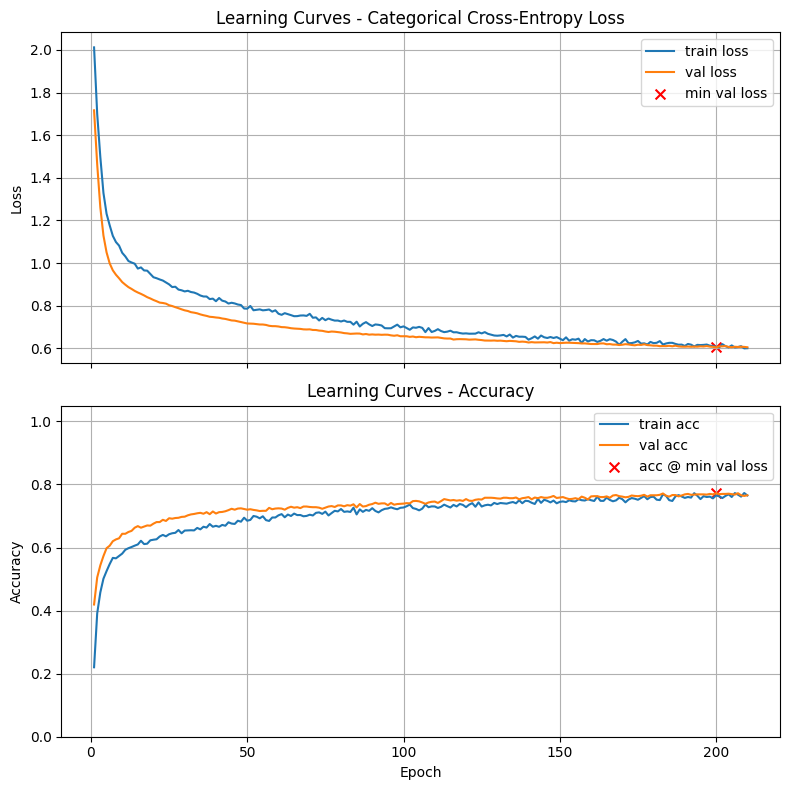

Final Training Loss:            0.6005
Final Training Accuracy:        0.7652
Final Validation Loss:          0.6050
Final Validation Accuracy:      0.7657
Minimum Validation Loss:        0.6044 (Epoch 200)
Validation Accuracy @ Min Loss: 0.7721

Test Loss: 0.6289
Test Accuracy: 0.7493

Validation-Test Gap (accuracy): 0.022857

Execution Time: 00:00:22


In [243]:
# introduce exp decay
from tensorflow.keras.optimizers.schedules import CosineDecay

decay = ExponentialDecay(initial_learning_rate=1e-3, decay_steps=5_000, decay_rate=0.9)

final_model_trial2 = build_model(
    n_inputs=X_train.shape[1], 
    # (width, act, l2_lambda, dropout_rate)
    layer_list=[
        (64, 'relu', 1e-4, 0.4),
        (32, 'relu', 1e-3, 0.1)
    ], 
    n_classes=n_classes
)
print(final_model_trial2.summary())
train_and_test(model=final_model_trial2, lr_schedule=5e-4)

In [244]:
# Set a6 to the validation accuracy found by this best model

a6 = 0.7814             # Replace 0.0 with your answer

In [245]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a6 = {a6:.4f}') 

a6 = 0.7814


### Optional: Print out your results of all experiments

In [246]:
print_results()

Learning Curves                         	0.7721


## Reflection Questions (ungraded)

It would be a great idea to think through your answers to these questions, then give ChatGPT (or other AI tool) a PDF of your
homework, and **discuss** (not just ask) these. 

1. Activation Functions:

    - Why do you think one activation function worked better than the others for this task?
    
    - How might this choice differ for deeper or wider networks?

2. Learning Rate:

    - Would a much smaller learning rate (with many more epochs) likely produce better accuracy?
    
    - When is it worth training longer with a smaller step size, and when is it unnecessary?

3. Dropout vs. L2:

    - Which form of regularization — dropout or L2 — gave better results in your experiments?
    
    - Why might one method be more effective in this setting?

4. Combining Dropout and L2:

    - Why might the combination of dropout and L2 sometimes perform worse than using one method alone?
    
    - What does this tell you about the balance between bias and variance in regularization?

5. Best Model:

    - When you designed your best model, what trade-offs did you notice between model complexity, training stability, and generalization?
    
    - Did learning rate scheduling (if you tried it) improve results? Why might it help?